In [15]:
# Install required libraries
!pip install pandas numpy matplotlib statsmodels scikit-learn


In [16]:
# Import all necessary libraries
import numpy as np                                           # For numerical operations
import pandas as pd                                          # For data manipulation
import matplotlib.pyplot as plt                             
from statsmodels.tsa.seasonal import seasonal_decompose      
from statsmodels.tsa.stattools import adfuller               
from statsmodels.tsa.arima.model import ARIMA                
from statsmodels.tsa.statespace.sarimax import SARIMAX       
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from sklearn.metrics import mean_squared_error               
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [17]:
# Load the Air Passengers dataset
# This dataset contains monthly airline passenger counts from 1949 to 1960
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df  = pd.read_csv(url, header=0)

# Rename columns for clarity
df.columns = ['Month', 'Passengers']

# Convert Month column to datetime format
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as index for time series analysis
df.set_index('Month', inplace=True)

print("Dataset loaded successfully!")
print(f"\nShape      : {df.shape[0]} months x {df.shape[1]} column")
print(f"Date Range : {df.index.min()} to {df.index.max()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic Statistics:")
print(df.describe())

Dataset loaded successfully!

Shape      : 144 months x 1 column
Date Range : 1949-01-01 00:00:00 to 1960-12-01 00:00:00

First 5 rows:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Basic Statistics:
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


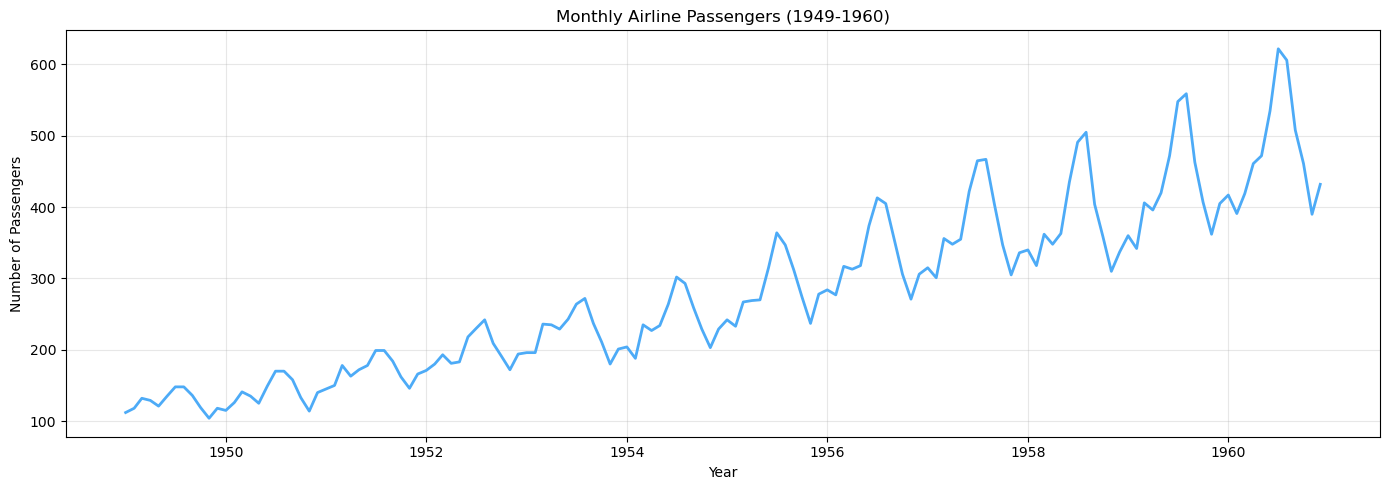

Raw time series chart saved as 'timeseries_raw.png'


In [19]:
# Plot the raw time series data
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Passengers'], color='#4dabf7', linewidth=2)
plt.title('Monthly Airline Passengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('timeseries_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print("Raw time series chart saved as 'timeseries_raw.png'")

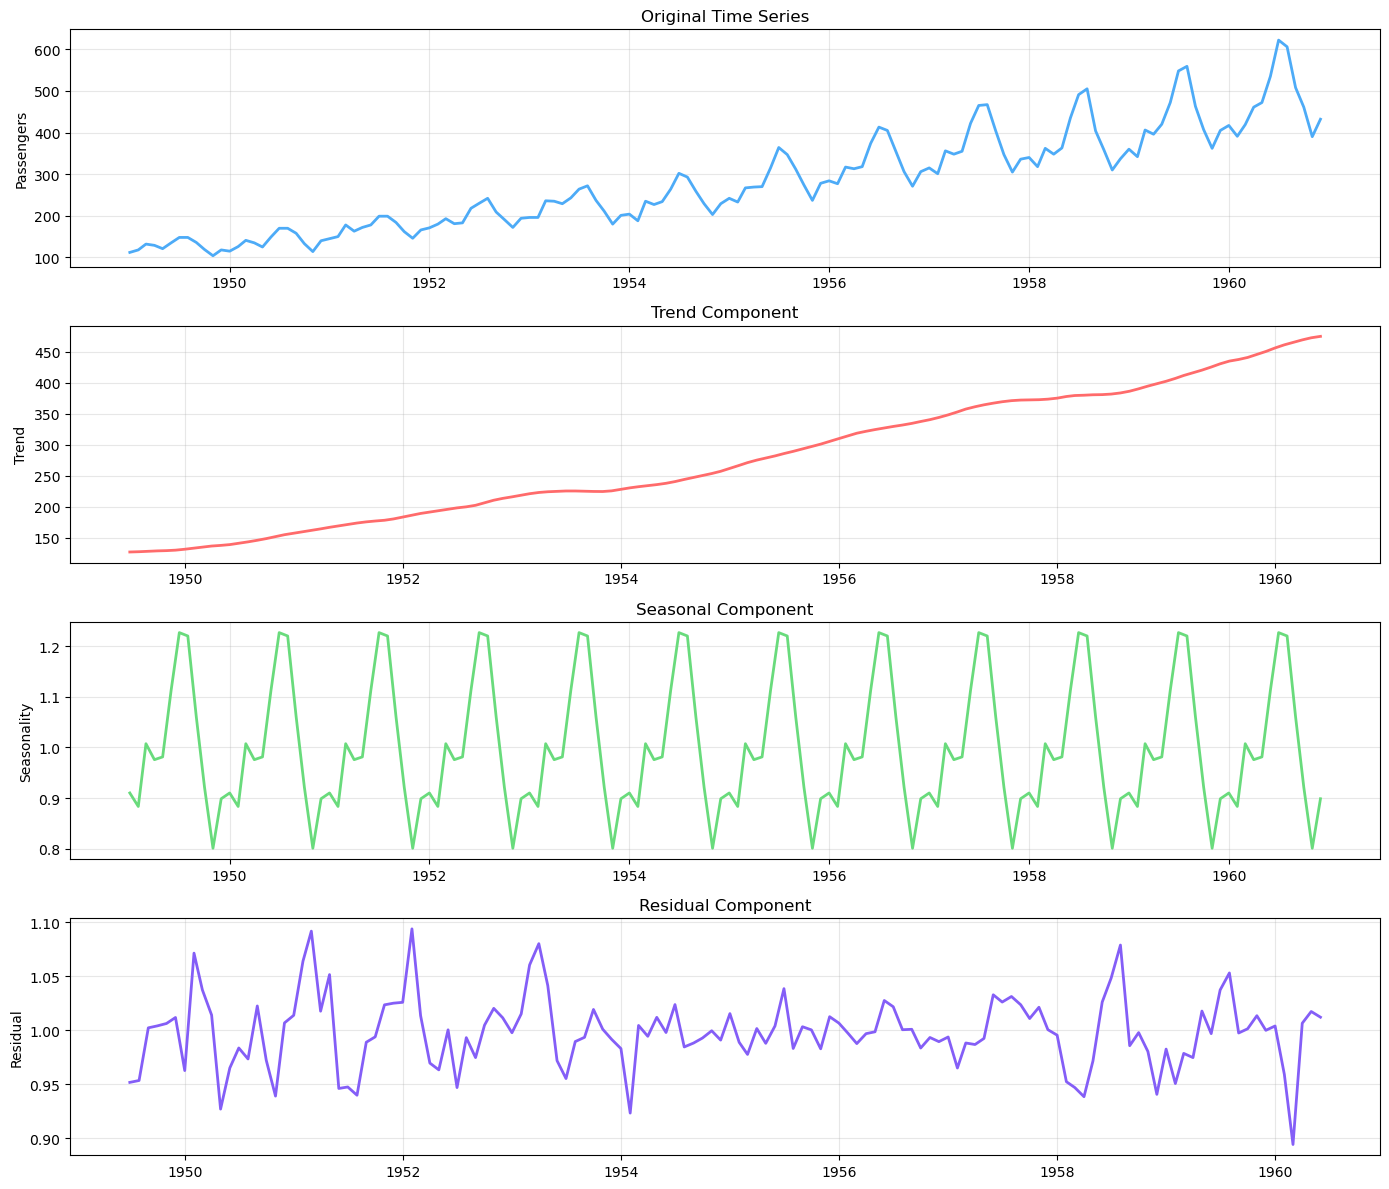

Decomposition chart saved as 'timeseries_decomposition.png'


In [20]:
# Decompose time series into Trend, Seasonality, and Residual components
# multiplicative model used because seasonality grows with trend
decomposition = seasonal_decompose(
    df['Passengers'],
    model='multiplicative',    # Use multiplicative because variance increases over time
    period=12                  # 12 months = 1 year seasonal period
)

# Plot all 4 components
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original data
axes[0].plot(df.index, df['Passengers'], color='#4dabf7', linewidth=2)
axes[0].set_title('Original Time Series')
axes[0].set_ylabel('Passengers')
axes[0].grid(True, alpha=0.3)

# Trend component
axes[1].plot(decomposition.trend.index, decomposition.trend, color='#ff6b6b', linewidth=2)
axes[1].set_title('Trend Component')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Seasonal component
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color='#69db7c', linewidth=2)
axes[2].set_title('Seasonal Component')
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, alpha=0.3)

# Residual component
axes[3].plot(decomposition.resid.index, decomposition.resid, color='#845ef7', linewidth=2)
axes[3].set_title('Residual Component')
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('timeseries_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print("Decomposition chart saved as 'timeseries_decomposition.png'")

In [21]:
# Augmented Dickey-Fuller test to check if series is stationary
# Stationary = mean and variance constant over time
# ARIMA requires stationary data

def check_stationarity(series, name="Series"):
    """
    Perform ADF test and print results
    H0: Series is non-stationary
    If p-value < 0.05, series is stationary
    """
    result = adfuller(series.dropna())

    print(f"ADF Test Results for {name}:")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Result        : {'Stationary ✅' if result[1] < 0.05 else 'Non-Stationary ❌'}")
    return result[1] < 0.05

# Check original series
is_stationary = check_stationarity(df['Passengers'], "Original Series")

if not is_stationary:
    print("\nApplying log transformation to stabilize variance...")
    df['Log_Passengers'] = np.log(df['Passengers'])

    print("\nApplying differencing to remove trend...")
    df['Diff_Passengers'] = df['Log_Passengers'].diff()

    check_stationarity(df['Diff_Passengers'].dropna(), "After Log + Differencing")
    

ADF Test Results for Original Series:
  ADF Statistic : 0.8154
  p-value       : 0.9919
  Result        : Non-Stationary ❌

Applying log transformation to stabilize variance...

Applying differencing to remove trend...
ADF Test Results for After Log + Differencing:
  ADF Statistic : -2.7171
  p-value       : 0.0711
  Result        : Non-Stationary ❌


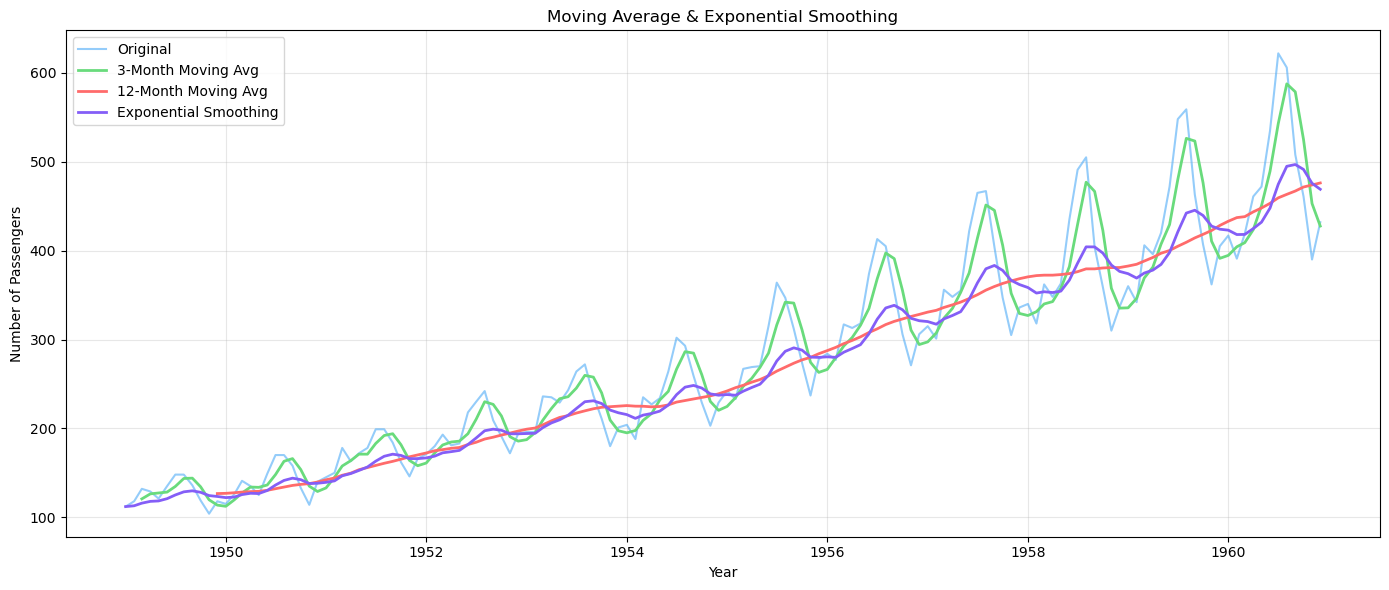

Smoothing chart saved as 'smoothing_techniques.png'


In [22]:
# Apply Moving Average and Exponential Smoothing techniques

# Moving Average - smooths out short-term fluctuations
df['MA_12'] = df['Passengers'].rolling(window=12).mean()   # 12-month moving average
df['MA_3']  = df['Passengers'].rolling(window=3).mean()    # 3-month moving average

# Exponential Smoothing - gives more weight to recent observations
df['EWM']   = df['Passengers'].ewm(span=12, adjust=False).mean()

# Plot all smoothing techniques
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Passengers'], color='#4dabf7', linewidth=1.5, alpha=0.6, label='Original')
plt.plot(df.index, df['MA_3'],       color='#69db7c', linewidth=2, label='3-Month Moving Avg')
plt.plot(df.index, df['MA_12'],      color='#ff6b6b', linewidth=2, label='12-Month Moving Avg')
plt.plot(df.index, df['EWM'],        color='#845ef7', linewidth=2, label='Exponential Smoothing')
plt.title('Moving Average & Exponential Smoothing')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('smoothing_techniques.png', dpi=150, bbox_inches='tight')
plt.show()

print("Smoothing chart saved as 'smoothing_techniques.png'")

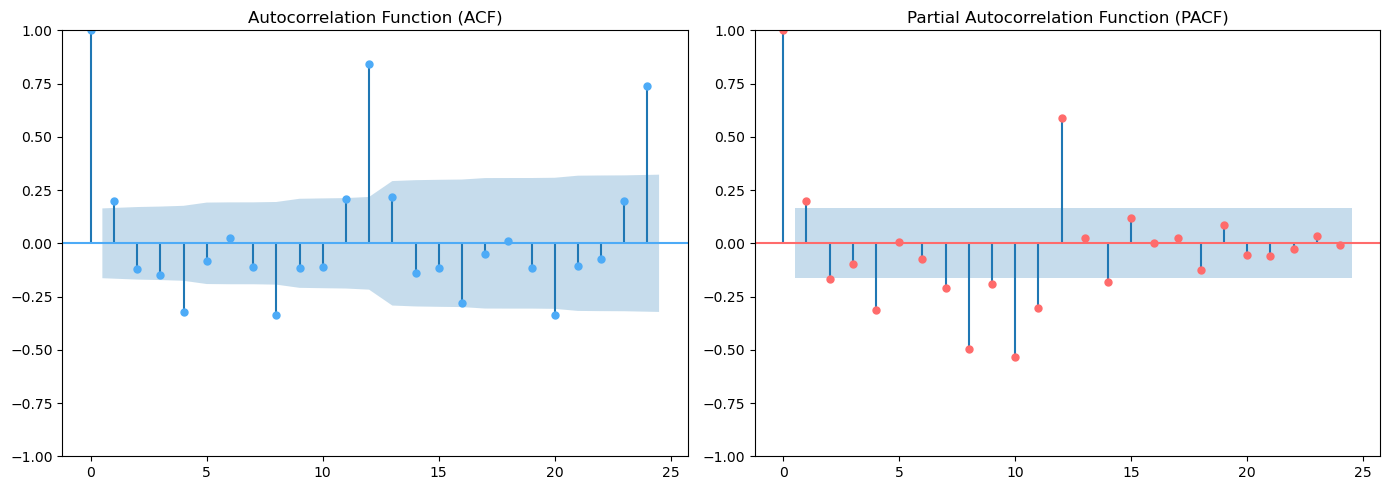

ACF/PACF charts saved as 'acf_pacf.png'


In [23]:

# ACF (AutoCorrelation Function) and PACF (Partial AutoCorrelation Function)
# Used to determine ARIMA parameters (p, d, q)
# ACF  -> helps find q (MA order)
# PACF -> helps find p (AR order)

log_diff = df['Log_Passengers'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF Plot
plot_acf(log_diff, lags=24, ax=axes[0], color='#4dabf7')
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF Plot
plot_pacf(log_diff, lags=24, ax=axes[1], color='#ff6b6b')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print("ACF/PACF charts saved as 'acf_pacf.png'")

In [24]:
# Split data into training (80%) and testing (20%)
train_size = int(len(df) * 0.8)
train_data = df['Passengers'][:train_size]
test_data  = df['Passengers'][train_size:]

print(f"Training set : {len(train_data)} months")
print(f"Testing set  : {len(test_data)} months")

# Build ARIMA model
# p=2 (AR order), d=1 (differencing), q=2 (MA order)
arima_model = ARIMA(
    np.log(train_data),     # Log transform for stationarity
    order=(2, 1, 2)         # (p, d, q) parameters
)
arima_result = arima_model.fit()

print("\nARIMA Model Summary:")
print(arima_result.summary())

Training set : 115 months
Testing set  : 29 months

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  115
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 104.653
Date:                Wed, 27 May 2026   AIC                           -199.305
Time:                        20:19:13   BIC                           -185.624
Sample:                    01-01-1949   HQIC                          -193.753
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2477      0.188      1.321      0.187      -0.120       0.615
ar.L2          0.2582      0.242      1.069      0.285    

In [25]:
# Build SARIMA model (handles seasonality better than ARIMA)
# SARIMA(p,d,q)(P,D,Q,s) where s=12 for monthly seasonality
sarima_model = SARIMAX(
    np.log(train_data),
    order=(1, 1, 1),              # Non-seasonal parameters (p,d,q)
    seasonal_order=(1, 1, 1, 12)  # Seasonal parameters (P,D,Q,s)
)
sarima_result = sarima_model.fit(disp=False)

print("SARIMA Model fitted successfully!")
print("\nSARIMA Model Summary:")
print(sarima_result.summary())

SARIMA Model fitted successfully!

SARIMA Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  115
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 189.041
Date:                            Wed, 27 May 2026   AIC                           -368.083
Time:                                    20:19:16   BIC                           -354.958
Sample:                                01-01-1949   HQIC                          -362.768
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2376      0.330     -0.720      0.472   

Model Evaluation:
  ARIMA  RMSE : 82.8782
  SARIMA RMSE : 15.1851

  Better Model: SARIMA ✅


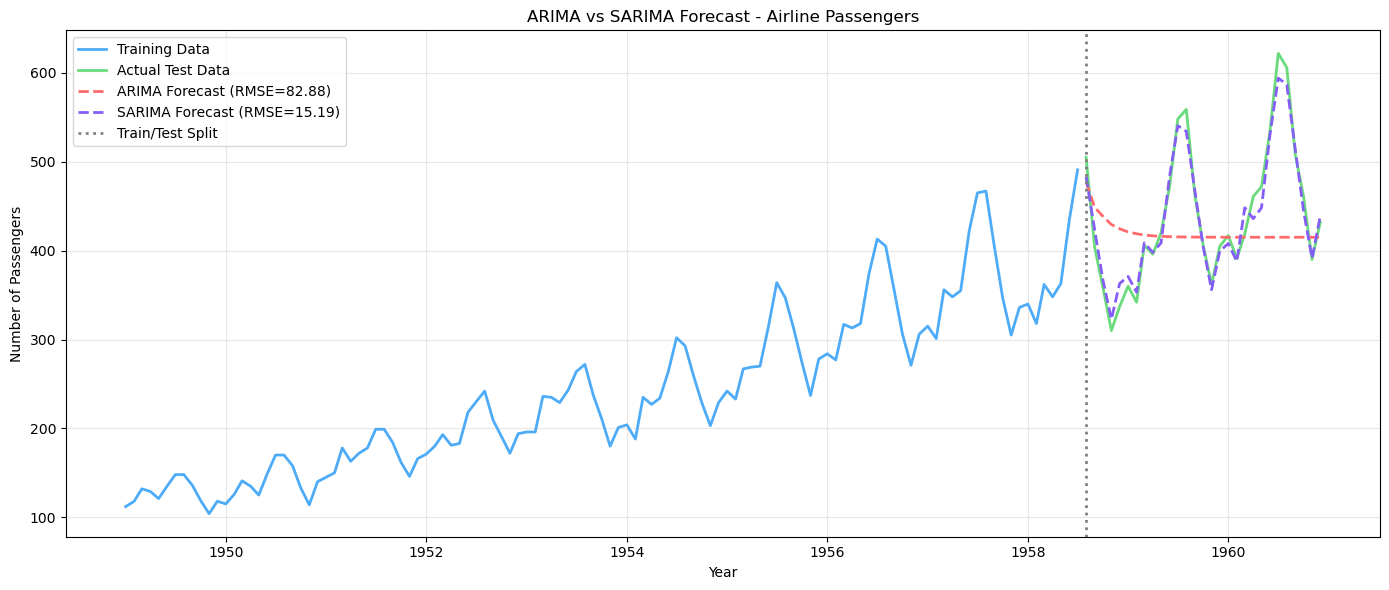

Forecast chart saved as 'forecast_results.png'


In [26]:
# Forecast using both models
forecast_steps = len(test_data)

# ARIMA Forecast
arima_forecast_log = arima_result.forecast(steps=forecast_steps)
arima_forecast     = np.exp(arima_forecast_log)   # Reverse log transform

# SARIMA Forecast
sarima_forecast_log = sarima_result.forecast(steps=forecast_steps)
sarima_forecast     = np.exp(sarima_forecast_log)   # Reverse log transform

# Calculate RMSE for both models
arima_rmse  = np.sqrt(mean_squared_error(test_data, arima_forecast))
sarima_rmse = np.sqrt(mean_squared_error(test_data, sarima_forecast))

print(f"Model Evaluation:")
print(f"  ARIMA  RMSE : {arima_rmse:.4f}")
print(f"  SARIMA RMSE : {sarima_rmse:.4f}")
print(f"\n  Better Model: {'SARIMA ✅' if sarima_rmse < arima_rmse else 'ARIMA ✅'}")

# Plot forecasts
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data,          color='#4dabf7', linewidth=2,  label='Training Data')
plt.plot(test_data.index,  test_data,           color='#69db7c', linewidth=2,  label='Actual Test Data')
plt.plot(test_data.index,  arima_forecast,      color='#ff6b6b', linewidth=2,  linestyle='--', label=f'ARIMA Forecast (RMSE={arima_rmse:.2f})')
plt.plot(test_data.index,  sarima_forecast,     color='#845ef7', linewidth=2,  linestyle='--', label=f'SARIMA Forecast (RMSE={sarima_rmse:.2f})')
plt.axvline(x=test_data.index[0], color='gray', linestyle=':', linewidth=2,    label='Train/Test Split')
plt.title('ARIMA vs SARIMA Forecast - Airline Passengers')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Forecast chart saved as 'forecast_results.png'")

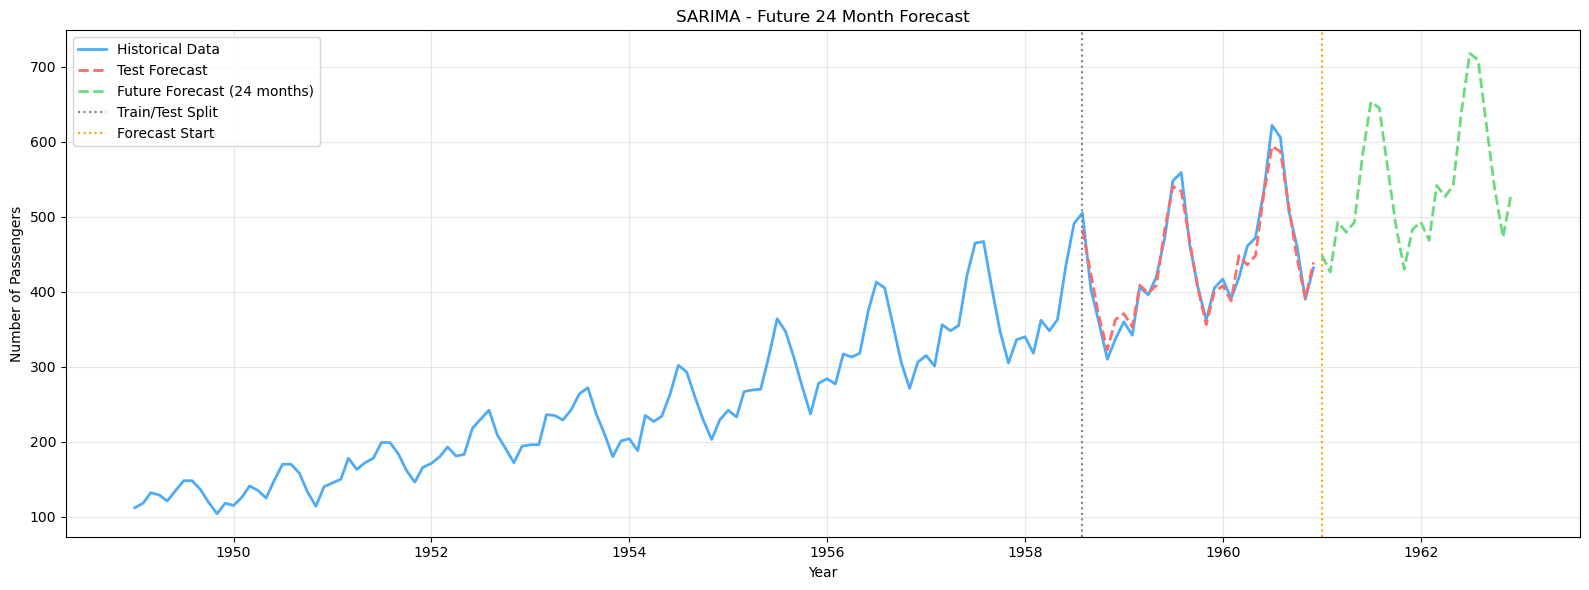

Future forecast chart saved as 'future_forecast.png'


In [27]:
# Forecast next 24 months into the future using best model
future_steps = 24

# Use SARIMA for future forecast (better with seasonality)
future_forecast_log = sarima_result.forecast(steps=len(test_data) + future_steps)
future_forecast     = np.exp(future_forecast_log)

# Create future date index
last_date    = df.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=future_steps,
    freq='MS'
)

# Plot full forecast including future
plt.figure(figsize=(16, 6))
plt.plot(df.index,       df['Passengers'],                     color='#4dabf7', linewidth=2,             label='Historical Data')
plt.plot(test_data.index, sarima_forecast,                     color='#ff6b6b', linewidth=2, linestyle='--', label='Test Forecast')
plt.plot(future_dates,    future_forecast[-future_steps:],     color='#69db7c', linewidth=2, linestyle='--', label='Future Forecast (24 months)')
plt.axvline(x=test_data.index[0],  color='gray',  linestyle=':', linewidth=1.5, label='Train/Test Split')
plt.axvline(x=future_dates[0],     color='orange', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title('SARIMA - Future 24 Month Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("Future forecast chart saved as 'future_forecast.png'")

In [28]:
print("=" * 60)
print("  TASK 1 - TIME SERIES ANALYSIS - SUMMARY")
print("=" * 60)
print(f"\n  Dataset         : Airline Passengers (1949-1960)")
print(f"  Total Months    : {len(df)}")
print(f"  Training Set    : {train_size} months")
print(f"  Testing Set     : {len(test_data)} months")
print(f"\n  Model Performance:")
print(f"    ARIMA  RMSE   : {arima_rmse:.4f}")
print(f"    SARIMA RMSE   : {sarima_rmse:.4f}")
print(f"    Best Model    : {'SARIMA' if sarima_rmse < arima_rmse else 'ARIMA'}")
print(f"\n  Key Findings:")
print(f"    - Clear upward trend in passenger numbers")
print(f"    - Strong seasonal pattern (peaks in summer months)")
print(f"    - SARIMA handles seasonality better than ARIMA")
print(f"\n  Files Saved:")
print(f"    - timeseries_raw.png")
print(f"    - timeseries_decomposition.png")
print(f"    - smoothing_techniques.png")
print(f"    - acf_pacf.png")
print(f"    - forecast_results.png")
print(f"    - future_forecast.png")
print("=" * 60)

  TASK 1 - TIME SERIES ANALYSIS - SUMMARY

  Dataset         : Airline Passengers (1949-1960)
  Total Months    : 144
  Training Set    : 115 months
  Testing Set     : 29 months

  Model Performance:
    ARIMA  RMSE   : 82.8782
    SARIMA RMSE   : 15.1851
    Best Model    : SARIMA

  Key Findings:
    - Clear upward trend in passenger numbers
    - Strong seasonal pattern (peaks in summer months)
    - SARIMA handles seasonality better than ARIMA

  Files Saved:
    - timeseries_raw.png
    - timeseries_decomposition.png
    - smoothing_techniques.png
    - acf_pacf.png
    - forecast_results.png
    - future_forecast.png
